# SSH and Rice-Mele Chains

**Model.** The SSH model is a two-sublattice single-particle tight-binding chain with alternating hoppings. The Rice-Mele model extends SSH by adding staggered onsite potentials.

**Typical uses.** Boundary-mode demonstrations, topological-chain intuition, dimerization studies, finite-spectrum checks, and quantum-walk test matrices.

**Parameters.** `n_cells` sets the number of two-site unit cells $N_c$; `t1` and `t2` set the SSH intracell and intercell hoppings $t_1$ and $t_2$; `hopping` sets the Rice-Mele mean hopping $t$; `dimerization` sets the hopping dimerization $\delta$; `staggering` sets the onsite staggering $\Delta_{\mathrm{RM}}$; and `periodic` controls boundary conditions.

**Useful plots.** Sorted spectra, site probabilities of near-zero modes, and comparisons of edge localization across parameters.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import rice_mele_model, ssh_edge_state_localizations, ssh_model
from quantum_lattice_models.plotting import plot_site_probabilities, plot_spectrum
from quantum_lattice_models.spectra import eigensystem

In [2]:
n_cells = 12
ssh = ssh_model(n_cells=n_cells, t1=0.35, t2=1.0, periodic=False)
rice_mele = rice_mele_model(n_cells=n_cells, hopping=1.0, dimerization=0.35, staggering=0.4)

print("model      | shape    | key parameters")
print("---        | ---      | ---")
print(
    f"SSH        | {str(ssh.shape):<8s} | "
    f"t1={ssh.metadata['t1']:.2f}, t2={ssh.metadata['t2']:.2f}, "
    f"periodic={ssh.metadata['periodic']}"
)
print(
    f"Rice-Mele  | {str(rice_mele.shape):<8s} | "
    f"hopping={rice_mele.metadata['hopping']:.2f}, "
    f"dimerization={rice_mele.metadata['dimerization']:.2f}, "
    f"staggering={rice_mele.metadata['staggering']:.2f}"
)

model      | shape    | key parameters
---        | ---      | ---
SSH        | (24, 24) | t1=0.35, t2=1.00, periodic=False
Rice-Mele  | (24, 24) | hopping=1.00, dimerization=0.35, staggering=0.40


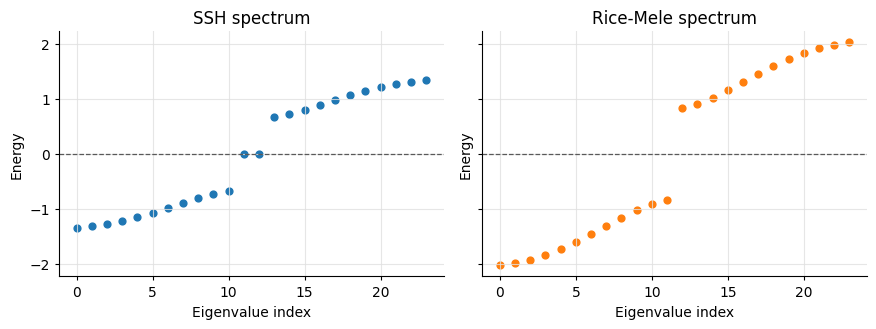

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
plot_spectrum(ssh, ax=axes[0], color="tab:blue")
axes[0].axhline(0.0, color="0.35", linestyle="--", linewidth=0.9)
axes[0].set_title("SSH spectrum")
plot_spectrum(rice_mele, ax=axes[1], color="tab:orange")
axes[1].axhline(0.0, color="0.35", linestyle="--", linewidth=0.9)
axes[1].set_title("Rice-Mele spectrum")
fig.tight_layout()

SSH near-zero states
state | energy | edge weight
---   | ---    | ---
   12 |  2.965266e-06 | 0.984994
   11 | -2.965266e-06 | 0.984994


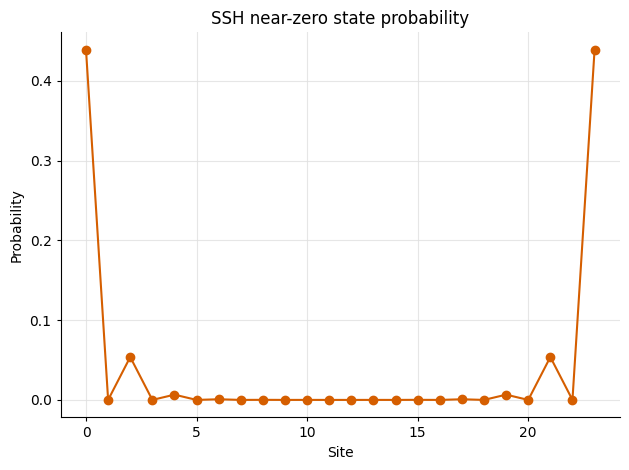

In [4]:
values, vectors = eigensystem(ssh)
near_zero = np.argsort(np.abs(values))[:2]
weights = ssh_edge_state_localizations(vectors[:, near_zero], n_cells=n_cells, edge_cells=2)
print("SSH near-zero states")
print("state | energy | edge weight")
print("---   | ---    | ---")
for state, energy, weight in zip(near_zero, values[near_zero], weights, strict=False):
    print(f"{state:>5d} | {energy: .6e} | {weight:.6f}")

ax = plot_site_probabilities(vectors[:, near_zero[0]], title="SSH near-zero state probability")
ax.figure.tight_layout()